# Preprocessing and Grouping

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('phivolcs_earthquake_oct.csv')

df.head()

,Date_Time_PH,Latitude,Longitude,Depth_In_Km,Magnitude,Location,Specific_Location,General_Location,date
0,2025-12-30 19:10:00,11.96,122.29,10.0,4.2,020 km N 9° E of Tangalan (Aklan),Tangalan,Aklan,2025-12-30 19:10:00
1,2025-12-30 19:02:00,9.69,126.24,28.0,1.4,014 km S 40° E of General Luna (Surigao Del No...,General Luna,Surigao Del Norte,2025-12-30 19:02:00
2,2025-12-30 17:58:00,17.84,120.54,31.0,2.2,010 km S 73° E of Sinait (Ilocos Sur),Sinait,Ilocos Sur,2025-12-30 17:58:00
3,2025-12-30 16:49:00,10.00,126.10,32.0,2.3,003 km S 42° E of Burgos (Surigao Del Norte),Burgos,Surigao Del Norte,2025-12-30 16:49:00
4,2025-12-30 15:27:00,6.40,126.75,14.0,3.6,079 km S 25° E of Tarragona (Davao Oriental),Tarragona,Davao Oriental,2025-12-30 15:27:00


In [3]:
print(df.shape)

(117599, 9)


In [4]:
# CLEAN NUMERIC COLUMNS

# Replace hyphens with NaN
df = df.replace('-', np.nan)

# Convert numeric columns properly
numeric_cols = ['Latitude', 'Longitude', 'Depth_In_Km', 'Magnitude']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows that still contain NaN in these fields
df = df.dropna(subset=numeric_cols)

print(df.shape)

(117556, 9)


### Completeness threshold for magnitude

In [5]:
# completeness threshold for magnitude
df = df[df['Magnitude'] >= 1.9]
print(df.shape)

(98519, 9)


In [6]:
# Parse date format (e.g. 2025-12-09 02:50:00)
df['date'] = pd.to_datetime(df['date'])

# Copy depth & magnitude
df['depth'] = df['Depth_In_Km'].values
df['mag'] = df['Magnitude'].values

# Text features
# df['region'] = df['General_Location']

lat = df['Latitude'].values
lon = df['Longitude'].values

def hypocenter_to_xyz(lat, lon, depth):
  lat = np.radians(lat)
  lon = np.radians(lon)
  R = 6371  # Earth radius (km)

  r = R - depth  # move inward

  x = r * np.cos(lat) * np.cos(lon)
  y = r * np.cos(lat) * np.sin(lon)
  z = r * np.sin(lat)

  return x, y, z

x, y, z = hypocenter_to_xyz(df['Latitude'], df['Longitude'], df['Depth_In_Km'])

df['x'] = x
df['y'] = y
df['z'] = z

df.head()

,Date_Time_PH,Latitude,Longitude,Depth_In_Km,Magnitude,Location,Specific_Location,General_Location,date,depth,mag,x,y,z
0,2025-12-30 19:10:00,11.96,122.29,10.0,4.2,020 km N 9° E of Tangalan (Aklan),Tangalan,Aklan,2025-12-30 19:10:00,10.0,4.2,-3324.313118,5260.575925,1318.182170
2,2025-12-30 17:58:00,17.84,120.54,31.0,2.2,010 km S 73° E of Sinait (Ilocos Sur),Sinait,Ilocos Sur,2025-12-30 17:58:00,31.0,2.2,-3066.697610,5197.917938,1942.322033
3,2025-12-30 16:49:00,10.00,126.10,32.0,2.3,003 km S 42° E of Burgos (Surigao Del Norte),Burgos,Surigao Del Norte,2025-12-30 16:49:00,32.0,2.3,-3678.173947,5044.035496,1100.755798
4,2025-12-30 15:27:00,6.40,126.75,14.0,3.6,079 km S 25° E of Tarragona (Davao Oriental),Tarragona,Davao Oriental,2025-12-30 15:27:00,14.0,3.6,-3779.845458,5061.826944,708.608002
7,2025-12-30 15:22:00,13.11,124.26,32.0,2.6,011 km N 39° E of Prieto Diaz (Sorsogon),Prieto Diaz,Sorsogon,2025-12-30 15:22:00,32.0,2.6,-3475.526005,5102.579063,1437.820188


In [7]:
# scale coordinates

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['x','y','z', 'mag']] = scaler.fit_transform(df[['x','y','z', 'mag']])

df.head()

,Date_Time_PH,Latitude,Longitude,Depth_In_Km,Magnitude,Location,Specific_Location,General_Location,date,depth,mag,x,y,z
0,2025-12-30 19:10:00,11.96,122.29,10.0,4.2,020 km N 9° E of Tangalan (Aklan),Tangalan,Aklan,2025-12-30 19:10:00,10.0,2.389185,0.629714,1.222272,0.320805
2,2025-12-30 17:58:00,17.84,120.54,31.0,2.2,010 km S 73° E of Sinait (Ilocos Sur),Sinait,Ilocos Sur,2025-12-30 17:58:00,31.0,-0.732996,1.595301,0.614166,1.748003
3,2025-12-30 16:49:00,10.00,126.10,32.0,2.3,003 km S 42° E of Burgos (Surigao Del Norte),Burgos,Surigao Del Norte,2025-12-30 16:49:00,32.0,-0.576887,-0.696616,-0.879290,-0.176376
4,2025-12-30 15:27:00,6.40,126.75,14.0,3.6,079 km S 25° E of Tarragona (Davao Oriental),Tarragona,Davao Oriental,2025-12-30 15:27:00,14.0,1.452531,-1.077698,-0.706621,-1.073087
7,2025-12-30 15:22:00,13.11,124.26,32.0,2.6,011 km N 39° E of Prieto Diaz (Sorsogon),Prieto Diaz,Sorsogon,2025-12-30 15:22:00,32.0,-0.108560,0.062943,-0.311115,0.594377


In [8]:
print(df[['x','y','z']].describe())

# check if mean ~ 0 and std ~ 1

                  x             y             z
count  9.851900e+04  9.851900e+04  9.851900e+04
mean   2.927160e-15  1.121170e-14 -2.228222e-16
std    1.000005e+00  1.000005e+00  1.000005e+00
min   -9.643420e+00 -3.651411e+01 -2.262597e+00
25%   -8.387098e-01 -8.514027e-01 -7.584952e-01
50%   -4.192114e-01 -1.329979e-01 -2.137566e-01
75%    1.025000e+00  7.062602e-01  7.119502e-01
max    3.595105e+01  3.540498e+00  3.317789e+00


In [9]:
# keep checking date format

print(df['date'].head())
print(df['date'].dtype)

0   2025-12-30 19:10:00
2   2025-12-30 17:58:00
3   2025-12-30 16:49:00
4   2025-12-30 15:27:00
7   2025-12-30 15:22:00
Name: date, dtype: datetime64[ns]
datetime64[ns]


In [10]:
# MONTHLY GROUPING
# df['group'] = df['date'].dt.strftime('%Y-%m')
# groups = sorted(df['group'].unique())

In [11]:
# QUARTERLY GROUPING

df['year'] = df['date'].dt.year
df['quarter'] = df['date'].dt.quarter
df['group'] = df['year'].astype(str) + '-Q' + df['quarter'].astype(str)

groups = sorted(df['group'].unique())

print("Number of groups:", len(groups))
groups[:10]


Number of groups: 32


['2018-Q1',
 '2018-Q2',
 '2018-Q3',
 '2018-Q4',
 '2019-Q1',
 '2019-Q2',
 '2019-Q3',
 '2019-Q4',
 '2020-Q1',
 '2020-Q2']

In [12]:
print(df[['date','group']].head(20))
print(df['group'].nunique())

                  date    group
0  2025-12-30 19:10:00  2025-Q4
2  2025-12-30 17:58:00  2025-Q4
3  2025-12-30 16:49:00  2025-Q4
4  2025-12-30 15:27:00  2025-Q4
7  2025-12-30 15:22:00  2025-Q4
9  2025-12-30 13:15:00  2025-Q4
11 2025-12-30 12:08:00  2025-Q4
14 2025-12-30 10:25:00  2025-Q4
16 2025-12-30 09:53:00  2025-Q4
18 2025-12-30 08:02:00  2025-Q4
19 2025-12-30 07:50:00  2025-Q4
21 2025-12-30 06:31:00  2025-Q4
23 2025-12-30 06:04:00  2025-Q4
24 2025-12-30 05:52:00  2025-Q4
25 2025-12-30 05:30:00  2025-Q4
27 2025-12-30 04:47:00  2025-Q4
28 2025-12-30 04:37:00  2025-Q4
29 2025-12-30 04:37:00  2025-Q4
30 2025-12-30 04:02:00  2025-Q4
31 2025-12-30 03:45:00  2025-Q4
32


### Entries per group

In [13]:
print(df['group'].value_counts().sort_index())

group
2018-Q1    1069
2018-Q2    1544
2018-Q3    1533
2018-Q4    1833
2019-Q1    2234
2019-Q2    2698
2019-Q3    2114
2019-Q4    4697
2020-Q1    3123
2020-Q2    3266
2020-Q3    3293
2020-Q4    2855
2021-Q1    2224
2021-Q2    3052
2021-Q3    3202
2021-Q4    2548
2022-Q1    2541
2022-Q2    2842
2022-Q3    4045
2022-Q4    2698
2023-Q1    2704
2023-Q2    2765
2023-Q3    2683
2023-Q4    5348
2024-Q1    3866
2024-Q2    3634
2024-Q3    3850
2024-Q4    2871
2025-Q1    3041
2025-Q2    3350
2025-Q3    3223
2025-Q4    7773
Name: count, dtype: int64


In [14]:
groups = sorted(df['group'].unique())
print(len(groups))  # 96 → yay
# 120 for 10 yrs, 104 for 10 yrs w/ missing
# 32 groups for quarterly yay

32


## Feature_cols

In [15]:
feature_cols = ["x", "y", "z", "mag"]
# no more depth since alr adjusted back for x y z computation as these turned out to be hypocenters

In [16]:
seed = 42
rng = np.random.default_rng(seed) # for reproducibility

### Subsampling

In [17]:
# with subsampling
max_samples = 1000
n_samples = 1000

group_data = {}

for g in groups:
    # filter rows belonging to this group
    df_g = df[df["group"] == g]

    # extract features only
    X_g = df_g[feature_cols].values  # shape: (n_g, d)

    group_data[g] = X_g

# shuffle before subsampling to avoid ordering bias
for g in groups:
    X = group_data[g]

    if len(X) > max_samples:
        perm = rng.permutation(len(X))
        group_data[g] = X[perm[:max_samples]]

# subsampling part
for g in groups:
    X = group_data[g]

    if len(X) > max_samples:
        idx = rng.choice(len(X), max_samples, replace=False)
        group_data[g] = X[idx]

In [18]:
counts = [len(group_data[g]) for g in groups]

print("Min:", min(counts))
print("Max:", max(counts))
print("Mean:", np.mean(counts))

Min: 1000
Max: 1000
Mean: 1000.0


# Kernel Density Estimation

In [19]:
from sklearn.neighbors import KernelDensity

group_kdes = {}
bandwidth = 0.05

for g in groups:
  Xg = group_data[g]

  kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth)
  kde.fit(Xg)

  group_kdes[g] = kde

# Bhattacharya Coefficient

In [44]:
from sklearn.utils import check_random_state

rng = check_random_state(seed)

def bhattacharyya_between_kdes(kde_p, kde_q, n_samples, rng):
  rng = rng

  Xp = kde_p.sample(n_samples, random_state=rng)
  Xq = kde_q.sample(n_samples, random_state=rng)

  lp_p = kde_p.score_samples(Xp)
  lp_q = kde_q.score_samples(Xp)

  lq_p = kde_p.score_samples(Xq)
  lq_q = kde_q.score_samples(Xq)

  bc_p = np.mean(np.exp(0.5 * (lp_q - lp_p)))
  bc_q = np.mean(np.exp(0.5 * (lq_p - lq_q)))

  BC = 0.5 * (bc_p + bc_q)
  BC = np.clip(BC, 0.0, 1.0)

  return BC

In [42]:
# sanity check
kde_a = group_kdes["2018-Q1"]

rng = np.random.RandomState(seed)

Xp = kde_a.sample(5, random_state=rng)

lp_p = kde_a.score_samples(Xp)
lp_q = kde_a.score_samples(Xp)

print(lp_p)
print(lp_q)
print(lp_q - lp_p)
print(np.exp(0.5 * (lp_q - lp_p)))

[ 0.60880274 -3.05470939  1.0970955   0.11796089 -2.09394338]
[ 0.60880274 -3.05470939  1.0970955   0.11796089 -2.09394338]
[0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1.]


In [45]:
# bhattacharya coefficient (angular distance) validation

kde_p = group_kdes["2018-Q1"]
kde_q = group_kdes["2021-Q3"]

n_samples=100000

# re-call rngs for random samples
rng1=np.random.RandomState(seed)
rng2=np.random.RandomState(seed)
rng3=np.random.RandomState(seed)

# SYMMETRY TEST
# BC(P,Q) == BC(Q,P)

bc_pq = bhattacharyya_between_kdes(
    kde_p,
    kde_q,
    n_samples,
    rng1
)

bc_qp = bhattacharyya_between_kdes(
    kde_q,
    kde_p,
    n_samples,
    rng2
)

symmetry_diff = abs(bc_pq - bc_qp)

print("SYMMETRY TEST")
print("-" * 40)
print(f"BC(P,Q) : {bc_pq:.10f}")
print(f"BC(Q,P) : {bc_qp:.10f}")
print(f"Difference : {symmetry_diff:.10e}")

# IDENTITY TEST
# BC(P,P) should be close to 1
# Angular distance should be close to 0

bc_identity = bhattacharyya_between_kdes(
    kde_p,
    kde_p,
    n_samples,
    rng3
)

angular_identity = np.arccos(
    np.clip(bc_identity, -1.0, 1.0)
)

print("\nIDENTITY TEST")
print("-" * 40)
print(f"BC(P,P) : {bc_identity:.10f}")
print(f"Angular Distance(P,P) : {angular_identity:.10e}")

# BOUNDS TEST
# check if 0 <= arccos(BC) <= pi/2
# since BC is bounded [0, 1]

angular_pq = np.arccos(
    np.clip(bc_pq, -1.0, 1.0)
)

within_bounds = (
    0.0 <= angular_pq <= (np.pi / 2)
)

print("\nBOUNDS TEST")
print("-" * 40)
print(f"Angular Distance(P,Q) : {angular_pq:.10f}")
print(f"Lower Bound Satisfied : {angular_pq >= 0.0}")
print(f"Upper Bound Satisfied : {angular_pq <= (np.pi / 2)}")
print(f"Within Bounds Overall : {within_bounds}")

SYMMETRY TEST
----------------------------------------
BC(P,Q) : 0.2824539859
BC(Q,P) : 0.2823446463
Difference : 1.0933963766e-04

IDENTITY TEST
----------------------------------------
BC(P,P) : 1.0000000000
Angular Distance(P,P) : 0.0000000000e+00

BOUNDS TEST
----------------------------------------
Angular Distance(P,Q) : 1.2844450258
Lower Bound Satisfied : True
Upper Bound Satisfied : True
Within Bounds Overall : True


number of groups G

In [46]:
groups = sorted(group_data.keys())
G = len(groups)

Fisher distance matrix and Bhattacharyya coeffs

Fisher distance:
$F_{fine} = cos^{-1}(BC)$

In [47]:
from tqdm import tqdm
from sklearn.utils import check_random_state
import numpy as np

rng = check_random_state(seed)

F = np.zeros((G, G))  # Fisher distance matrix

for i in tqdm(range(G)):
    for j in range(i+1, G):
        BC = bhattacharyya_between_kdes(
            group_kdes[groups[i]],
            group_kdes[groups[j]],
            n_samples=1000,
            rng=rng
        )

        # Fisher distance
        F_fine = np.arccos(BC)

        F[i, j] = F[j, i] = F_fine

# diagonal = 0
np.fill_diagonal(F, 0.0)

100%|██████████| 32/32 [01:44<00:00,  3.25s/it]


In [48]:
# GEODESIC

from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path

k = int(np.sqrt(G))

A = kneighbors_graph(F, n_neighbors=k, mode='distance', include_self=False)

# make symmetric
A = 0.5 * (A + A.T)

# compute geodesic distances
G_geo = shortest_path(A, method='D')

In [81]:
# MDS

from sklearn.manifold import MDS

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=seed)
Y_bc = mds.fit_transform(G_geo)

In [83]:
np.savez("BCF_mag.npz", Y=Y_bc, groups=groups)

In [56]:
# Sanity check

print("F range:", F.min(), F.max())
print("Geodesic range:", G_geo.min(), G_geo.max())
print("Embedding shape:", Y_bc.shape)

F range: 0.0 1.475703702543928
Geodesic range: 0.0 4.49035339611112
Embedding shape: (32, 2)


In [57]:
# plotting again

time_continuous = np.arange(Y_bc.shape[0])
if np.corrcoef(Y_bc[:,0], time_continuous)[0,1] < 0:
  Y_bc[:,0] *= -1

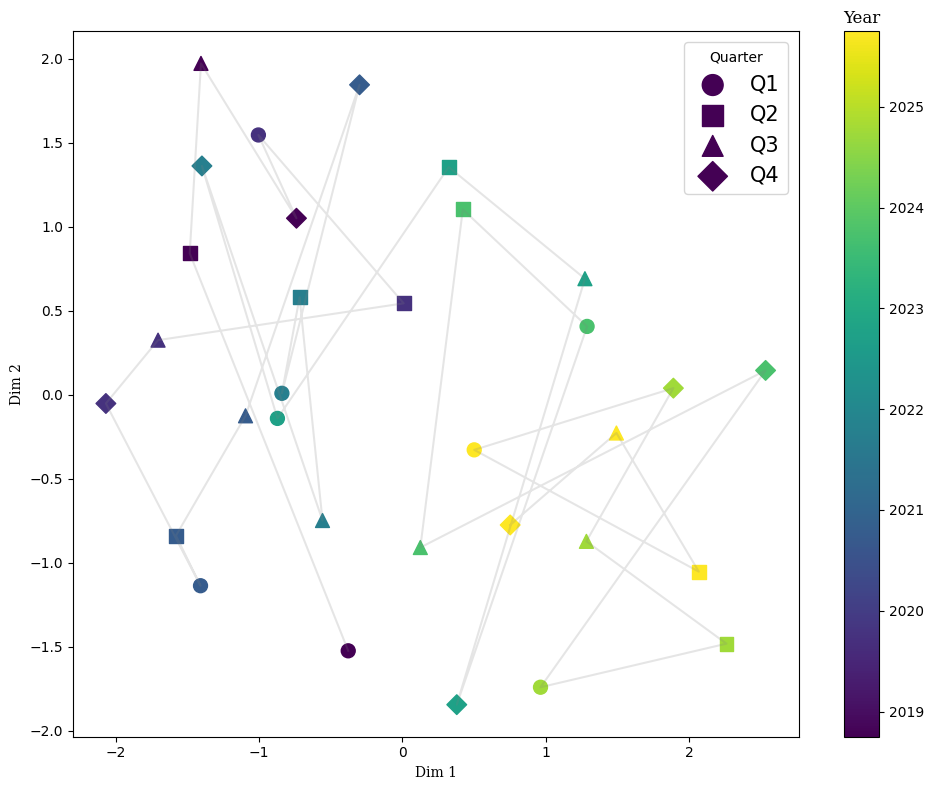

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

years = np.array([int(g[:4]) for g in groups])
quarters = np.array([int(g.split('-Q')[1]) for g in groups])
time_continuous = years + (quarters - 1)/4

markers = {1:'o', 2:'s', 3:'^', 4:'D'}

for q in [1,2,3,4]:
    idx = np.where(quarters == q)

    sc = plt.scatter(
        Y_bc[idx,0], Y_bc[idx,1],
        c=time_continuous[idx],
        cmap='viridis',
        s=100,
        marker=markers[q],
        label=f"Q{q}"
    )

# colorbar on top
cbar = plt.colorbar(sc)
cbar.ax.set_title("Year", fontname="DejaVu Serif")

plt.legend(title="Quarter", fontsize=15, markerscale=1.5)

#connect trajectory
order = np.argsort(time_continuous)
plt.plot(Y_bc[order,0], Y_bc[order,1], color='gray', alpha=0.2)

plt.xlabel("Dim 1", fontname="DejaVu Serif")
plt.ylabel("Dim 2", fontname="DejaVu Serif")

plt.tight_layout()
plt.show()

In [68]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=3,
    min_samples=1,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

labels = clusterer.fit_predict(Y_bc)

In [69]:
Y_bc.shape

(32, 2)

In [70]:
labels

array([-1,  4,  4,  4,  4,  0,  4,  4, -1, -1,  3, -1,  3,  4, -1,  4,  3,
        0,  2, -1,  2,  0,  1,  2, -1, -1,  1,  2,  1, -1,  2,  1])

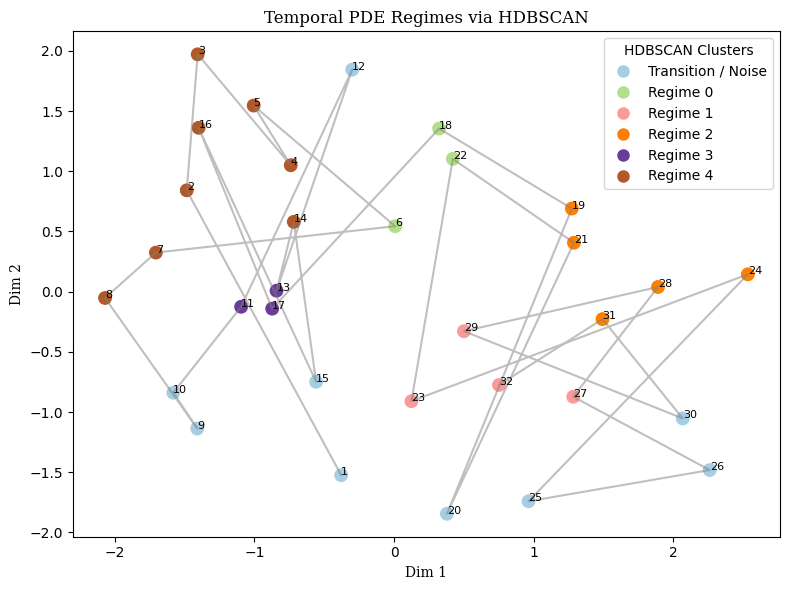

In [80]:
# embedding but w/ regimes

import matplotlib.pyplot as plt
import matplotlib.lines as mlines


plt.figure(figsize=(8,6))

scatter = plt.scatter(
    Y_bc[:,0],
    Y_bc[:,1],
    c=labels,
    cmap='Paired',
    s=80
)

# connect trajectory
plt.plot(
    Y_bc[:,0],
    Y_bc[:,1],
    color='gray',
    alpha=0.5
)

# annotate time index
for i, (x,y) in enumerate(Y_bc):
  plt.text(x, y, str(i+1), fontsize=8)

unique_labels = np.unique(labels)

# get colors from scatter colormap
colors = scatter.cmap(
    scatter.norm(unique_labels)
)

legend_handles = []

for lbl, color in zip(unique_labels, colors):
    if lbl == -1:
        name = "Transition / Noise"
    else:
        name = f"Regime {lbl}"

    handle = mlines.Line2D(
        [],
        [],
        color=color,
        marker='o',
        linestyle='None',
        markersize=8,
        label=name
    )
    legend_handles.append(handle)

plt.legend(
    handles=legend_handles,
    title="HDBSCAN Clusters",
  # bbox_to_anchor=(1.05, 1),
    loc='best'
)

plt.xlabel("Dim 1", fontname="DejaVu Serif")
plt.ylabel("Dim 2", fontname="DejaVu Serif")
plt.title("Temporal PDE Regimes via HDBSCAN",  fontname="DejaVu Serif")
plt.tight_layout()
plt.show()

In [84]:
clusterer.probabilities_

array([0.        , 1.        , 0.90082106, 0.93672848, 1.        ,
       1.        , 0.93688643, 0.93688643, 0.        , 0.        ,
       1.        , 0.        , 1.        , 0.93672848, 0.        ,
       1.        , 1.        , 1.        , 0.97806335, 0.        ,
       0.97806335, 1.        , 0.84322818, 1.        , 0.        ,
       0.        , 1.        , 1.        , 1.        , 0.        ,
       1.        , 1.        ])

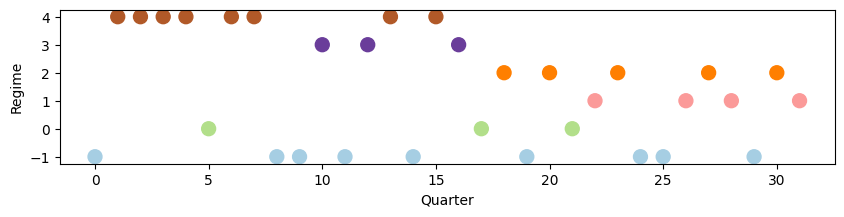

In [85]:
plt.figure(figsize=(10,2))

plt.scatter(range(len(labels)), labels, c=labels, cmap='Paired', s=100)

plt.xlabel("Quarter")
plt.ylabel("Regime")
plt.yticks(sorted(set(labels)))
plt.show()

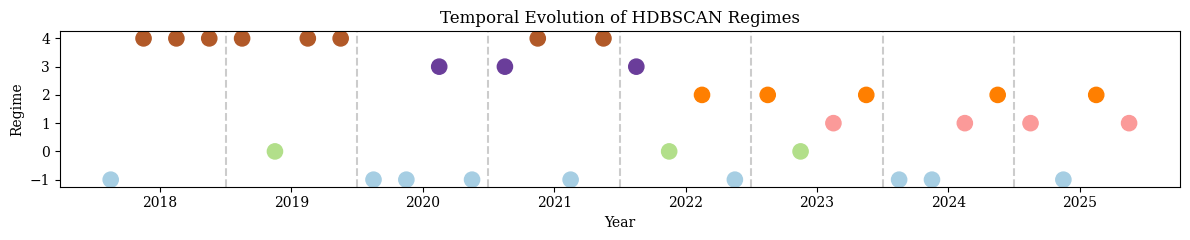

In [89]:
import numpy as np
import matplotlib.pyplot as plt

years = np.arange(2018, 2026)   # 2018–2025
x_positions = np.arange(len(labels))

plt.figure(figsize=(12,2.5))

plt.scatter(
    x_positions,
    labels,
    c=labels,
    cmap='Paired',
    s=120
)

# vertical separators between years
for x in range(4, len(labels), 4):
    plt.axvline(x - 0.5, color='gray', linestyle='--', alpha=0.4)

# place ticks at center of each year block
year_centers = np.arange(1.5, len(labels), 4)

plt.xticks(year_centers, years, fontname="DejaVu Serif")

plt.xlabel("Year", fontname="DejaVu Serif")
plt.ylabel("Regime", fontname="DejaVu Serif")
plt.yticks(sorted(set(labels)), fontname="DejaVu Serif")

plt.title("Temporal Evolution of HDBSCAN Regimes", fontname="DejaVu Serif")

plt.tight_layout()
plt.show()

In [35]:
clusterer.cluster_persistence_

array([0.27478717, 0.27673744, 0.05703799, 0.17926085, 0.13094026])

In [36]:
for i, p in enumerate(clusterer.cluster_persistence_):
    print(i, p)

0 0.2747871682639551
1 0.2767374412640002
2 0.057037989746994984
3 0.1792608529824649
4 0.13094025844047225


In [37]:
np.savez("FINE_quarterly_mag_0.05_MC1.9.npz", Y_fine=Y_fine, groups=groups)

## 3d eme

In [ ]:
mds3 = MDS(n_components=3, dissimilarity='precomputed', random_state=42)
Y3 = mds3.fit_transform(F)

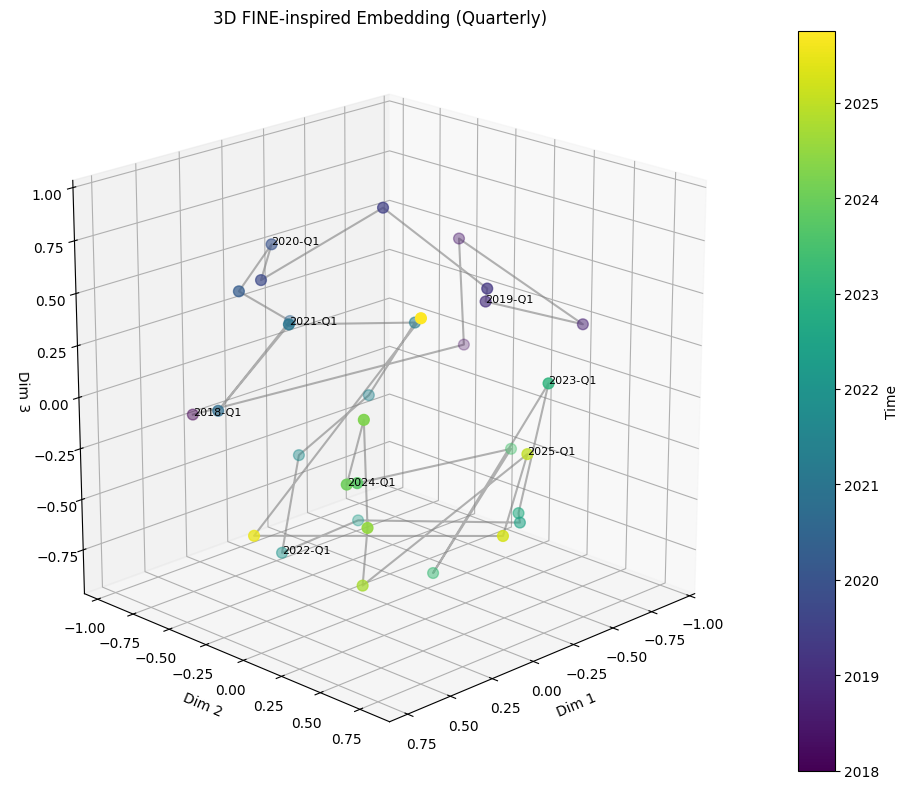

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    Y3[:,0], Y3[:,1], Y3[:,2],
    c=time_continuous,
    cmap='viridis',
    s=60
)

order = np.argsort(time_continuous)

ax.plot(
    Y3[order,0],
    Y3[order,1],
    Y3[order,2],
    color='gray',
    alpha=0.6
)

for i in range(0, len(groups), 4):
    ax.text(
        Y3[i,0], Y3[i,1], Y3[i,2],
        groups[i],
        fontsize=8
    )

ax.view_init(elev=20, azim=45)
ax.set_box_aspect([1,1,1])

ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.set_zlabel("Dim 3")
ax.set_title("3D FINE-inspired Embedding (Quarterly)")

fig.colorbar(sc, label="Time")

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    x=Y3[:,0],
    y=Y3[:,1],
    z=Y3[:,2],
    color=time_continuous,
    title="3D Embedding"
)

fig.show()

In [ ]:
print("3D MDS stress:", mds3.stress_)

3D MDS stress: 4.002714275352967


In [ ]:
from scipy.spatial.distance import pdist, squareform
import numpy as np

dist_Y3 = squareform(pdist(Y3))

stress3_norm = np.sqrt(
    np.sum((dist_Y3 - F)**2) / np.sum(F**2)
)

print("Normalized 3D stress:", stress3_norm)

Normalized 3D stress: 0.2078867323729375


### 4D and 5D eme

In [ ]:
# 4D MDS
mds4 = MDS(n_components=4, dissimilarity='precomputed', random_state=42)
Y4 = mds4.fit_transform(F)

In [ ]:
print("4D MDS stress:", mds4.stress_)

3D MDS stress: 2.4253027595105996


In [ ]:
from scipy.spatial.distance import pdist, squareform
import numpy as np

dist_Y4 = squareform(pdist(Y4))

stress4_norm = np.sqrt(
    np.sum((dist_Y4 - F)**2) / np.sum(F**2)
)

print("Normalized 4D stress:", stress4_norm)

Normalized 4D stress: 0.16170463124086776


In [ ]:
# 5D MDS
mds5 = MDS(n_components=5, dissimilarity='precomputed', random_state=42)
Y5 = mds5.fit_transform(F)

In [ ]:
print("5D MDS stress:", mds5.stress_)

5D MDS stress: 1.694713509658663


In [ ]:
from scipy.spatial.distance import pdist, squareform
import numpy as np

dist_Y5 = squareform(pdist(Y5))

stress5_norm = np.sqrt(
    np.sum((dist_Y5 - F)**2) / np.sum(F**2)
)

print("Normalized 5D stress:", stress5_norm)

Normalized 5D stress: 0.13508523116625104


# interpretation / validation

In [ ]:
print("raw MDS stress:", mds.stress_)

raw MDS stress: 117.80793386695515


In [ ]:
from scipy.spatial.distance import pdist, squareform
import numpy as np

dist_Y = squareform(pdist(Y_bc))

stress_norm = np.sqrt(
    np.sum((dist_Y - F)**2) / np.sum(F**2)
)

print("Normalized stress:", stress_norm)

Normalized stress: 1.303952229734826


In [ ]:
# Distance preservation
from scipy.spatial.distance import pdist, squareform

dist_Y = squareform(pdist(Y_bc))
corr_dist = np.corrcoef(dist_Y.flatten(), F.flatten())[0,1]

print("Distance preservation:", corr_dist)

Distance preservation: 0.4458715833259854


In [ ]:
# intrinsic dimensionality
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(Y_bc)

print(pca.explained_variance_ratio_)

[0.77782423 0.22217577]
